# Razlikovanje benignih i malignih lezija na ultrazvučnim snimcima dojke

Sveska prati postupak izložen u poglavljima 4 i 5 rada: pripremu podataka,
obučavanje modela, eksperimente i završnu evaluaciju. Pisana je za okruženje
Kaggle Notebooks; putevi do skupova podataka podešavaju se u prvoj ćeliji.
Skupovi se ne nalaze u repozitorijumu - uputstvo za preuzimanje dato je u
datoteci README.md.

In [29]:
## 1. Priprema okruženja i podataka   (ćelije 0–2)
## 2. Podela na podskupove            (ćelije 3–4)
## 3. Model i obučavanje              (ćelija 5)
## 4. Eksperiment: šum i poređenje    (ćelija 6)
## 5. Eksperiment: uticaj podele      (ćelija 7)
## 6. Eksperiment: generalizacija     (ćelija 8)
## 7. Finalna evaluacija              (ćelije 9–11)
## 8. Slike za rad                    (ćelije 12–16)

## 1. Priprema okruženja

Pronalaženje i povezivanje ulaznih skupova (BUSI, BUS-BRA, BUS-UCLM) na
Kaggle-u. Ovaj korak je specifičan za svako okruženje; pri pokretanju u
drugom okruženju menja se samo ova ćelija.

In [30]:
# ============================================================================
# CELIJA 1 
# ============================================================================

import os
from pathlib import Path
 
KAGGLE_INPUT = Path("/kaggle/input")
DATA_ROOT    = Path("/kaggle/tmp/data")      # ovde nastaju BUSI, BUSBRA, BUSUCLM
META_DIR     = KAGGLE_INPUT / "bus-meta"     # manifest.csv i split_fixed.csv
OUTPUT_DIR   = Path("/kaggle/working")       # modeli i rezultati
 
DATA_ROOT.mkdir(parents=True, exist_ok=True)
 
 
def find_path_by_name(name):
    """Trazi fajl ili folder sa datim imenom bilo gde ispod /kaggle/input.
    Ako ima vise pogodaka, vraca onaj na najmanjoj dubini."""
    matches = []
    for path in KAGGLE_INPUT.rglob(name):
        matches.append(path)
 
    if len(matches) == 0:
        raise RuntimeError(
            f"nije nadjeno '{name}' ispod {KAGGLE_INPUT}. "
            f"proveri da li si dodao skup kroz Add Input."
        )
 
    matches.sort(key=lambda path: len(path.parts))
    return matches[0]
 
 
def link_dataset(link_name, marker_name, use_parent):
    """Pravi vezu DATA_ROOT/link_name -> folder u kome zivi marker.
 
    use_parent = True   marker je fajl ili podfolder, uzima se njegov roditelj
    use_parent = False  marker je sam trazeni folder
    """
    link_path = DATA_ROOT / link_name
    if link_path.exists():
        print(f"{link_name}: vec povezan")
        return
 
    found = find_path_by_name(marker_name)
    target = found.parent if use_parent else found
    os.symlink(target, link_path)
    print(f"{link_name}: {target}")
 
 
link_dataset("BUSI",    "Dataset_BUSI_with_GT", use_parent=False)
link_dataset("BUSBRA",  "bus_data.csv",         use_parent=True)
link_dataset("BUSUCLM", "bus_uclm_separated",   use_parent=True)
 
print("\nsadrzaj:")
for dataset_dir in sorted(DATA_ROOT.iterdir()):
    print(f"  {dataset_dir.name}/")
    for item in sorted(dataset_dir.iterdir())[:6]:
        print(f"     {item.name}")
 
KAGGLE_INPUT = Path("/kaggle/input")
DATA_ROOT    = Path("/kaggle/tmp/data")
OUTPUT_DIR   = Path("/kaggle/working")

META_DIR = find_path_by_name("manifest.csv").parent
print(f"\nMETA_DIR: {META_DIR}")

BUSI: vec povezan
BUSBRA: vec povezan
BUSUCLM: vec povezan

sadrzaj:
  BUSBRA/
     Images
     LICENSE.txt
     Masks
     bus_data.csv
  BUSI/
     benign
     malignant
     normal
  BUSUCLM/
     BUS-UCLM Breast ultrasound lesion segmentation dataset
     bus_uclm_separated

META_DIR: /kaggle/input/datasets/jankobiznismen/bus-meta


## 2. Učitavanje podataka i grupisanje

Definicije funkcija za učitavanje tri skupa, detekciju duplikata pomoću dHash-a i grupisanje snimaka istog pacijenta (poglavlja 4.3 i 4.5).
Ćelija sadrži samo definicije; primena sledi u narednim ćelijama.

In [31]:
# ============================================================================
# CELIJA 2 
# ============================================================================
 
import numpy as np
import pandas as pd
from PIL import Image
 
 
def make_match_key(file_name):
    """Kljuc po kome se slika sparuje sa maskom.
    Iz 'bus_0001-l.png' i 'mask_0001-l.png' oba puta ispada '0001-l'."""
    return Path(file_name).stem.split("_")[-1]
 
 
def load_busi(dataset_dir=None):
    if dataset_dir is None:
        dataset_dir = DATA_ROOT / "BUSI"
 
    rows = []
    multi_mask_count = 0
    for class_name in ["benign", "malignant", "normal"]:
        class_dir = dataset_dir / class_name
        for image_path in sorted(class_dir.glob("*.png")):
            if "_mask" in image_path.stem:
                continue
            mask_paths = sorted(class_dir.glob(image_path.stem + "_mask*.png"))
            if len(mask_paths) > 1:
                multi_mask_count += 1
            rows.append({
                "path": str(image_path),
                "label": class_name,
                "source": "BUSI",
                "patient_id": None,          # BUSI nema podatak o pacijentu
                "mask_path": str(mask_paths[0]) if mask_paths else None,
                "n_masks": len(mask_paths),
                "birads": None, "device": None, "doppler": None, "marks": None,
            })
 
    table = pd.DataFrame(rows)
    assert len(table) == 780, f"BUSI: ocekivano 780, dobijeno {len(table)}"
    if multi_mask_count:
        print(f"  upozorenje: {multi_mask_count} BUSI slika ima vise od jedne "
              f"maske; koristi se prva, pa isecak moze da izostavi drugu leziju")
    return table
 
 
def load_busbra(dataset_dir=None):
    if dataset_dir is None:
        dataset_dir = DATA_ROOT / "BUSBRA"
 
    info = pd.read_csv(dataset_dir / "bus_data.csv")
    mask_by_key = {make_match_key(p.name): str(p)
                   for p in (dataset_dir / "Masks").glob("*.png")}
 
    rows = []
    for _, record in info.iterrows():
        image_path = dataset_dir / "Images" / (str(record["ID"]) + ".png")
        key = make_match_key(str(record["ID"]))
        rows.append({
            "path": str(image_path),
            "label": str(record["Pathology"]).strip().lower(),
            "source": "BUSBRA",
            # bus_0001-l i bus_0001-r su ISTI slucaj snimljen iz dva ugla
            "patient_id": "BUSBRA_" + str(record["Case"]),
            "mask_path": mask_by_key.get(key),
            "n_masks": 1 if key in mask_by_key else 0,
            "birads": record["BIRADS"], "device": record["Device"],
            "doppler": None, "marks": None,
        })
 
    table = pd.DataFrame(rows)
    assert len(table) == 1875, f"BUSBRA: ocekivano 1875, dobijeno {len(table)}"
    assert table["patient_id"].nunique() == 1064, "BUSBRA: broj slucajeva nije 1064"
    # skup je potpuno segmentiran; get() bi tiho vratio None i isecanje bi
    # kasnije dobilo red bez kutije
    assert table["n_masks"].sum() == 1875, \
        f"BUSBRA: {1875 - int(table['n_masks'].sum())} redova bez maske"
    return table
 
 
def find_segmentation_dir(dataset_dir, labels_dir_name):
    """iterdir() nema garantovan redosled, a manifest se od sada regenerise
    svake sesije -- izbor foldera ne sme da zavisi od redosleda."""
    candidates = sorted(p for p in dataset_dir.iterdir()
                        if p.is_dir() and p.name != labels_dir_name)
    assert len(candidates) == 1, (
        f"BUS-UCLM: ocekivan tacno jedan segmentacioni folder, nadjeno "
        f"{len(candidates)}: {[p.name for p in candidates]}")
    return candidates[0]
 
 
def load_busuclm(dataset_dir=None):
    if dataset_dir is None:
        dataset_dir = DATA_ROOT / "BUSUCLM"
 
    labels_dir = dataset_dir / "bus_uclm_separated"
    segmentation_dir = find_segmentation_dir(dataset_dir, labels_dir.name)
 
    mask_by_name = {}
    for candidate in segmentation_dir.rglob("*"):
        if candidate.is_dir() and "mask" in candidate.name.lower():
            for mask_path in candidate.glob("*.png"):
                mask_by_name[mask_path.name] = str(mask_path)
 
    # INFO.csv je razdvojen tackom-zarezom; Marks opisuje anotacije U slici
    info = None
    for info_path in sorted(segmentation_dir.rglob("INFO.csv")):
        info = pd.read_csv(info_path, sep=";")
        info["Image"] = info["Image"].astype(str).str.strip()
        info = info.set_index("Image")
        break
 
    rows = []
    for folder_name, label in [("benign", "benign"),
                               ("malign", "malignant"),   # folder je 'malign'
                               ("normal", "normal")]:
        for image_path in sorted((labels_dir / folder_name).glob("*.png")):
            meta = info.loc[image_path.name] if (
                info is not None and image_path.name in info.index) else None
            rows.append({
                "path": str(image_path),
                "label": label,
                "source": "BUSUCLM",
                # prefiks pre donje crte je oznaka pacijentkinje
                "patient_id": "UCLM_" + image_path.stem.split("_")[0],
                "mask_path": mask_by_name.get(image_path.name),
                "n_masks": 1 if image_path.name in mask_by_name else 0,
                "birads": None, "device": "Siemens ACUSON S2000",
                "doppler": None if meta is None else meta.get("Doppler"),
                "marks": None if meta is None else meta.get("Marks"),
            })
 
    table = pd.DataFrame(rows)
    assert len(table) == 683, f"BUS-UCLM: ocekivano 683, dobijeno {len(table)}"

    # 13 slika pacijentkinje HESN ima masku fiksnih dimenzija 856x606, dok su
    # same slike razlicito isecene (608x486 do 792x485). Maske nisu isecene
    # zajedno sa slikama, pa koordinate iz njih ne odgovaraju sadrzaju --
    # to je greska u samom skupu, ne zaokruzivanje.
    invalid_mask = []
    for index, row in table.iterrows():
        if pd.isna(row["mask_path"]):
            continue
        if Image.open(row["path"]).size != Image.open(row["mask_path"]).size:
            invalid_mask.append(index)

    if invalid_mask:
        print(f"  BUS-UCLM: {len(invalid_mask)} slika ima masku pogresnih "
              f"dimenzija, maska se odbacuje (slike ostaju u klasifikaciji)")
        table.loc[invalid_mask, "mask_path"] = None
        table.loc[invalid_mask, "n_masks"] = 0

    assert len(table) == 683, f"BUS-UCLM: ocekivano 683, dobijeno {len(table)}"
    return table

 
# ----------------------------------------------------------------------------
# Perceptualno hesiranje i grupisanje
# ----------------------------------------------------------------------------
def compute_dhash(image_path, size=8):
    """Sazima sliku u 64 bita: belezi samo da li je svaki piksel svetliji od
    svog desnog suseda. Prezivi promenu velicine, kompresiju i posvetljavanje,
    jer cuva odnose a ne apsolutne vrednosti."""
    image = Image.open(image_path).convert("L").resize((size + 1, size), Image.LANCZOS)
    pixels = np.asarray(image, dtype=np.int16)
    is_brighter = pixels[:, 1:] > pixels[:, :-1]
 
    bits = ""
    for value in is_brighter.flatten():
        bits = bits + ("1" if value else "0")
    return int(bits, 2)
 
 
# broj jedinica u svakom bajtu; koristi se za brzo poredjenje svih parova
_POPCOUNT = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)
 
 
def assign_groups(table, max_distance=4):
    """Svakoj slici dodeljuje broj grupe. Grupa je jedinica podele i pri
    deljenju podataka se ne razdvaja izmedju treninga i testa.
 
    compute_dhash ostaje citljiv radi objasnjenja u radu, ali se poredjenje
    svih parova vektorizuje -- 3338 slika je oko 5.5 miliona poredjenja.
    """
    print(f"racunam dHash za {len(table)} slika...")
    hashes = [compute_dhash(p) for p in table["path"]]
 
    n = len(hashes)
    packed = np.array(hashes, dtype=">u8").view(np.uint8).reshape(n, 8)
 
    parent = list(range(n))
    patient_ids = table["patient_id"].values
    # poznat ID pacijenta za koren svake komponente, ili None
    component_patient = {
        i: (None if patient_ids[i] is None or pd.isna(patient_ids[i])
            else patient_ids[i])
        for i in range(n)}
 
    def find_root(index):
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]
        return index
 
    def try_merge(index_a, index_b):
        """Spaja dve komponente ako to ne bi spojilo dva RAZLICITA poznata
        pacijenta. Provera ide na koren komponente, ne na pojedinacni par --
        inace bi put A -> slika bez ID-a -> B prosao neprimeceno.
 
        Napomena o redosledu: kad hes poveze sliku pacijenta P1 i sliku
        pacijenta P2 preko posrednika bez ID-a (BUSI slike ga nemaju), blokira
        se ono spajanje koje dodje DRUGO po redu. Koje je to zavisi od
        redosleda petlje, ali petlja ide po rastucem indeksu pa je ishod
        deterministican. Ogranicenje "dva razlicita poznata pacijenta nikad u
        istoj grupi" ne moze biti prekrseno ni u jednom redosledu.
        """
        root_a, root_b = find_root(index_a), find_root(index_b)
        if root_a == root_b:
            return
        patient_a, patient_b = component_patient[root_a], component_patient[root_b]
        if patient_a is not None and patient_b is not None and patient_a != patient_b:
            return                    # dHash je pretpostavka, ID pacijenta je cinjenica
        new_root, old_root = min(root_a, root_b), max(root_a, root_b)
        parent[old_root] = new_root
        component_patient[new_root] = patient_a if patient_a is not None else patient_b
 
    print("poredim hesove...")
    for i in range(n - 1):
        distances = _POPCOUNT[np.bitwise_xor(packed[i + 1:], packed[i])].sum(axis=1)
        for offset in np.nonzero(distances <= max_distance)[0]:
            try_merge(i, i + 1 + int(offset))
 
    # sve slike istog pacijenta u istu grupu, bez obzira na hes
    first_index_of_patient = {}
    for index, patient_id in enumerate(patient_ids):
        if patient_id is None or pd.isna(patient_id):
            continue
        if patient_id in first_index_of_patient:
            try_merge(index, first_index_of_patient[patient_id])
        else:
            first_index_of_patient[patient_id] = index
 
    return [find_root(index) for index in range(n)]
 
 
def check_mask_dimensions(table):
    """Kutija za isecanje se racuna PIL-om, a sece se TensorFlow-om, pa
    neslaganje dimenzija daje pogresan isecak.
 
    Provera ide nad SVIM slikama: Image.open().size cita samo zaglavlje i ne
    dekodira piksele, pa 3338 fajlova traje nekoliko sekundi. Uzorak od 200 bi
    pet problematicnih slika uhvatio sa oko 26% verovatnoce.
    """
    rows = table.dropna(subset=["mask_path"])
    mismatched = []
    for _, row in rows.iterrows():
        if Image.open(row["path"]).size != Image.open(row["mask_path"]).size:
            mismatched.append(row["path"])
    assert not mismatched, (
        f"{len(mismatched)} slika ima masku drugih dimenzija, npr. {mismatched[:5]}")
    print(f"  dimenzije maske i slike se poklapaju (sve {len(rows)} slika)")
 
 
def partitions_match(left_groups, right_groups):
    """Brojevi grupa su proizvoljni (koren je najmanji indeks), pa se poredi
    PODELA a ne oznake: svaka leva grupa mora da odgovara tacno jednoj desnoj
    i obrnuto."""
    frame = pd.DataFrame({"left": list(left_groups), "right": list(right_groups)})
    return (frame.groupby("left")["right"].nunique().max() == 1
            and frame.groupby("right")["left"].nunique().max() == 1)
 
 
def compare_with_canonical_manifest(computed):
    """Poredjenje mora da hvata i visak i manjak. Sa how='inner' plus provera
    duzine, regenerisani manifest sa 3400 redova bi prosao -- inner bi vratio
    3338 i sve bi izgledalo u redu."""
    canonical = pd.read_csv(META_DIR / "manifest.csv")
 
    comparison = canonical[["rel_path", "group"]].merge(
        computed[["rel_path", "group"]], on="rel_path", how="outer",
        suffixes=("_canonical", "_computed"), indicator=True)
 
    only_canonical = int((comparison["_merge"] == "left_only").sum())
    only_computed = int((comparison["_merge"] == "right_only").sum())
    assert only_canonical == 0 and only_computed == 0, (
        f"manifesti ne pokrivaju iste slike: samo u kanonskom {only_canonical}, "
        f"samo u regenerisanom {only_computed}")
 
    matched = comparison[comparison["_merge"] == "both"]
    if partitions_match(matched["group_canonical"], matched["group_computed"]):
        print(f"regenerisano grupisanje se poklapa sa kanonskim "
              f"({len(canonical)} slika)")
    else:
        differing = int((matched.groupby("group_canonical")["group_computed"]
                         .nunique() > 1).sum())
        print(f"grupisanje se NE poklapa: {differing} kanonskih grupa se razlaze")
        print("  -> dalje se koristi KANONSKI manifest, jer su svi dosadasnji")
        print("     rezultati vezani za njega")
    return canonical
 
 
def build_manifest():
    """Uvek preracunava, pa poredi sa kanonskim manifestom. Ako se ne poklapa,
    dosadasnji rezultati pripadaju grupisanju koje sveska ne ume da reprodukuje
    -- i to treba saznati odmah, a ne dva dana pred predaju."""
    computed = pd.concat([load_busi(), load_busbra(), load_busuclm()],
                         ignore_index=True)
    check_mask_dimensions(computed)
    computed["group"] = assign_groups(computed)
 
    computed["rel_path"] = [str(Path(p).relative_to(DATA_ROOT))
                            for p in computed["path"]]
    computed["rel_mask"] = [str(Path(p).relative_to(DATA_ROOT)) if pd.notna(p) else None
                            for p in computed["mask_path"]]
    computed = computed.drop(columns=["path", "mask_path"])
    computed.to_csv(OUTPUT_DIR / "manifest_regenerated.csv", index=False)
 
    return compare_with_canonical_manifest(computed)

### 2.1. Objedinjena evidencija (manifest)

Spajanje tri skupa u jedinstvenu evidenciju sa oznakom izvora, klase i grupe.

In [32]:
# ============================================================================
# CELIJA 3 -- manifest
# ============================================================================
 
manifest = build_manifest()
 
print()
print(pd.crosstab(manifest["source"], manifest["label"], margins=True))
 
grouped = manifest.groupby("group")
print(f"\ngrupa ukupno: {grouped.ngroups}")
print(f"grupa koje spajaju izvore: {(grouped['source'].nunique() > 1).sum()}")
print(f"grupa sa vise od jednog poznatog pacijenta: "
      f"{(grouped['patient_id'].nunique() > 1).sum()}   (mora biti 0)")
 
 

  upozorenje: 17 BUSI slika ima vise od jedne maske; koristi se prva, pa isecak moze da izostavi drugu leziju
  BUS-UCLM: 13 slika ima masku pogresnih dimenzija, maska se odbacuje (slike ostaju u klasifikaciji)
  dimenzije maske i slike se poklapaju (sve 3325 slika)
racunam dHash za 3338 slika...
poredim hesove...
regenerisano grupisanje se poklapa sa kanonskim (3338 slika)

label    benign  malignant  normal   All
source                                  
BUSBRA     1268        607       0  1875
BUSI        437        210     133   780
BUSUCLM     174         90     419   683
All        1879        907     552  3338

grupa ukupno: 1723
grupa koje spajaju izvore: 0
grupa sa vise od jednog poznatog pacijenta: 0   (mora biti 0)


## 3. Podela na podskupove

Definicije za StratifiedGroupKFold podelu na skup za obučavanje,
validacioni i test skup, uz provere koje sprečavaju curenje podataka
(poglavlje 4.6).

In [33]:
# ============================================================================
# CELIJA 4 
# ============================================================================
 
from sklearn.model_selection import StratifiedGroupKFold
 
SPLIT_SEED = 42
TRAIN_ONLY_SOURCES = ["BUSUCLM"]   # 264 slike na 36 grupa -- kao test skup daje
                                   # interval od oko +-22 procentna poena, a
                                   # stratifikacija na njemu pada
 
 
def load_binary_task(manifest):
    """Izbacuje klasu normal iz zadatka. Slike se ne brisu nego se ne koriste --
    potrebne su za analizu duplikata i anotacija."""
    table = manifest[manifest["label"] != "normal"].copy()
    table["y"] = (table["label"] == "malignant").astype(int)
    table["path"] = [str(DATA_ROOT / p) for p in table["rel_path"]]
    table["mask"] = [str(DATA_ROOT / p) if pd.notna(p) else None
                     for p in table["rel_mask"]]
    return table.reset_index(drop=True)
 
 
def generate_split(table):
    """Pravi podelu 60/20/20. Izvori iz TRAIN_ONLY_SOURCES idu celi u trening.
 
    Validacija je 20 posto, a ne 10, jer se NA NJOJ bira prag odluke za ciljanu
    senzitivnost -- procenjuje se deseti percentil skorova malignih, sto sa
    upola manje malignih grupa postaje osetno nestabilnije.
    """
    fixed = table[table["source"].isin(TRAIN_ONLY_SOURCES)].copy()
    pool = table[~table["source"].isin(TRAIN_ONLY_SOURCES)].copy().reset_index(drop=True)
 
    # stratifikuje se po kombinaciji izvora i klase
    stratify = pool["source"] + "_" + pool["y"].astype(str)
    fold = np.full(len(pool), -1)
    splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SPLIT_SEED)
    for fold_index, (_, indices) in enumerate(
            splitter.split(pool, stratify, groups=pool["group"])):
        fold[indices] = fold_index
 
    pool["split"] = np.where(fold == 0, "test",
                      np.where(fold == 1, "val", "train"))
    fixed["split"] = "train"
    return pd.concat([pool, fixed], ignore_index=True)
 
 
def load_split(table):
    """Generise podelu, poredi je sa kanonskom, i vraca KANONSKU.
 
    Identicnost nije uslov nego bonus. Originalni kod za podelu nastao je u
    drugom okruzenju, a ovo je rekonstrukcija -- moguce je da daje ekvivalentnu
    ali ne identicnu podelu. Ispravnost garantuju SVOJSTVA podele, koja
    proverava verify_split; identicnost je samo dokaz reproducibilnosti.
    """
    generated = generate_split(table)
    generated[["rel_path", "split"]].to_csv(
        OUTPUT_DIR / "split_regenerated.csv", index=False)
 
    canonical = pd.read_csv(META_DIR / "split_fixed.csv")[["rel_path", "split"]]
    comparison = canonical.merge(
        generated[["rel_path", "split"]], on="rel_path", how="outer",
        suffixes=("_canonical", "_generated"), indicator=True)
 
    only_canonical = int((comparison["_merge"] == "left_only").sum())
    only_generated = int((comparison["_merge"] == "right_only").sum())
    assert only_canonical == 0 and only_generated == 0, (
        f"podele ne pokrivaju iste slike: samo u kanonskoj {only_canonical}, "
        f"samo u regenerisanoj {only_generated}")
 
    mismatched = int((comparison["split_canonical"]
                      != comparison["split_generated"]).sum())
    if mismatched == 0:
        print(f"regenerisana podela je IDENTICNA kanonskoj ({len(canonical)} slika)")
    else:
        print(f"regenerisana podela se razlikuje u {mismatched} od "
              f"{len(canonical)} slika ({mismatched / len(canonical):.1%})")
        print("  -> dalje se koristi KANONSKA podela. U radu se navodi da je")
        print("     prilozeni kod rekonstrukcija koja daje ekvivalentnu podelu.")
        print(pd.crosstab(comparison["split_canonical"],
                          comparison["split_generated"]))
 
    return table.merge(canonical, on="rel_path", how="inner")
 
 
def verify_split(table):
    """Podela bez ovih provera je podela u koju nemas pravo da verujes."""
    print("\nslike po podskupu i izvoru:")
    print(pd.crosstab(table["split"], table["source"], margins=True))
    print("\nudeo malignih:")
    print(table.groupby(["split", "source"])["y"].mean().unstack().round(3))
    print("\ngrupa po podskupu: ", table.groupby("split")["group"].nunique().to_dict())
    print("malignih grupa:    ",
          table[table["y"] == 1].groupby("split")["group"].nunique().to_dict())
 
    # 1. curenje -- jedina greska koju ne smes da propustis
    assert table.groupby("group")["split"].nunique().max() == 1, \
        "curenje: ista grupa je u dva podskupa"
 
    # 2. izvori koji ne smeju u test zaista nisu tamo
    for source in TRAIN_ONLY_SOURCES:
        rows = table[table["source"] == source]
        if len(rows) > 0:
            assert set(rows["split"]) == {"train"}, f"{source} nije ceo u treningu"
 
    # 3. udeo malignih ujednacen; ova provera je uhvatila test od 90% malignih
    for source in table["source"].unique():
        if source in TRAIN_ONLY_SOURCES:
            continue
        ratios = table[table["source"] == source].groupby("split")["y"].mean()
        assert ratios.max() - ratios.min() < 0.06, \
            f"{source}: udeo malignih se razlikuje {ratios.to_dict()}"
 
    print("\npodela je ispravna")
 
 
# ----------------------------------------------------------------------------
# Kutije oko lezije
# ----------------------------------------------------------------------------
def bounding_box_from_mask(mask_path):
    """Najmanji pravougaonik koji sadrzi leziju, plus dimenzije slike.
 
    Maske BUS-UCLM skupa su RGB, a ne binarne -- boja kodira tip lezije.
    convert('L') ih svodi na sivo, pa je svaki piksel iznad nule deo lezije.
    """
    mask = np.asarray(Image.open(mask_path).convert("L"))
    height, width = mask.shape
    rows = np.where(mask.max(axis=1) > 0)[0]
    cols = np.where(mask.max(axis=0) > 0)[0]
    if len(rows) == 0 or len(cols) == 0:
        return 0, 0, height, width, height, width      # prazna maska -> cela slika
    return rows[0], cols[0], rows[-1] + 1, cols[-1] + 1, height, width
 
 
BOX_COLUMNS = ["y1", "x1", "y2", "x2", "img_h", "img_w"]
 
 
def attach_lesion_boxes(table):
    """Dodaje kolone kutije. Postojece se prvo brisu -- inace bi ponovno
    pokretanje celije napravilo y1_x i y1_y i sve nizvodno bi puklo."""
    table = table.drop(columns=[c for c in BOX_COLUMNS if c in table.columns])

    records = []
    for _, row in table.iterrows():
        if pd.isna(row["mask"]):
            # bez upotrebljive maske kutija je cela slika
            image = Image.open(row["path"])
            y1, x1, y2, x2 = 0, 0, image.size[1], image.size[0]
            h, w = image.size[1], image.size[0]
        else:
            y1, x1, y2, x2, h, w = bounding_box_from_mask(row["mask"])
        records.append({"rel_path": row["rel_path"], "y1": y1, "x1": x1, "y2": y2, "x2": x2, "img_h": h, "img_w": w})
        
    box_file = OUTPUT_DIR / "lesion_boxes.csv"
    if box_file.exists():
        boxes = pd.read_csv(box_file)
        print(f"ucitane kutije ({len(boxes)})")
    else:
        records = []
        for _, row in table.iterrows():
            y1, x1, y2, x2, h, w = bounding_box_from_mask(row["mask"])
            records.append({"rel_path": row["rel_path"], "y1": y1, "x1": x1,
                            "y2": y2, "x2": x2, "img_h": h, "img_w": w})
        boxes = pd.DataFrame(records)
        boxes.to_csv(box_file, index=False)
        print(f"izracunato {len(boxes)} kutija")
 
    merged = table.merge(boxes, on="rel_path", how="left")
    assert merged[BOX_COLUMNS].notna().all().all(), "nekim slikama fali kutija"
 
    area = ((merged["y2"] - merged["y1"]) * (merged["x2"] - merged["x1"])
            / (merged["img_h"] * merged["img_w"]))
    print(f"lezija zauzima {area.mean():.1%} slike u proseku "
          f"(min {area.min():.1%}, max {area.max():.1%}), "
          f"praznih maski: {(area >= 0.999).sum()}")
    return merged
 

### 3.1. Primena i provera podele

Izvršavanje podele i provera uravnoteženosti klasa po izvorima.

In [34]:
# ============================================================================
# CELIJA 5 -- primena podele
# ============================================================================
 
data = load_binary_task(manifest)
data = load_split(data)
verify_split(data)
data = attach_lesion_boxes(data)
 

regenerisana podela je IDENTICNA kanonskoj (2786 slika)

slike po podskupu i izvoru:
source  BUSBRA  BUSI  BUSUCLM   All
split                              
test       373   131        0   504
train     1122   380      264  1766
val        380   136        0   516
All       1875   647      264  2786

udeo malignih:
source  BUSBRA   BUSI  BUSUCLM
split                         
test     0.338  0.305      NaN
train    0.328  0.324    0.341
val      0.297  0.346      NaN

grupa po podskupu:  {'test': 319, 'train': 987, 'val': 319}
malignih grupa:     {'test': 108, 'train': 343, 'val': 104}

podela je ispravna
izracunato 2786 kutija
lezija zauzima 12.5% slike u proseku (min 0.2%, max 81.3%), praznih maski: 0


## 4. Model i obučavanje

Definicije pripreme snimka, augmentacije, postupka MixUp, konstrukcije
konvolucione mreže sa separabilnim konvolucijama i petlje obučavanja
(poglavlja 4.8, 4.9 i 4.10). Ćelija sadrži samo definicije.

In [35]:
# ============================================================================
# CELIJA 6 -- model i trening. Samo definicije.
# ============================================================================
 
import math
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score
 
# mora pre nego sto TensorFlow napravi ijedan graf
tf.config.experimental.enable_op_determinism()
keras.mixed_precision.set_global_policy("mixed_float16")
 
BATCH_SIZE = 32     # ne menjati: velicina batcha utice na sum gradijenta,
                    # dakle i na regularizaciju
NUM_EPOCHS = 100    # val AUC se zaustavio oko stote epohe
SEEDS = [1000, 1001, 1002]
 
 
def read_image(file_path, label, image_size):
    image = tf.io.decode_png(tf.io.read_file(file_path), channels=1)
    image = tf.image.convert_image_dtype(image, tf.float32)
    # resize_with_pad, ne obican resize: odnos visine i sirine lezije je
    # dijagnosticki znak, a rastezanje bi ga unistilo
    image = tf.image.resize_with_pad(image, image_size, image_size)
    return image, tf.cast(label, tf.float32)
 
 
def read_image_cropped(file_path, box, label, image_size):
    image = tf.io.decode_png(tf.io.read_file(file_path), channels=1)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.crop_to_bounding_box(
        image, box[0], box[1], box[2] - box[0], box[3] - box[1])
    image = tf.image.resize_with_pad(image, image_size, image_size)
    return image, tf.cast(label, tf.float32)
 
 
def build_augmentation(strength):
    """Vertikalnog obrtanja nema ni u jednoj jacini: zadnja akusticna senka je
    uvek ispod lezije, a koza i gel na vrhu slike, pa bi obrnuta slika bila
    anatomski nemoguca."""
    if strength == "weak":
        rotation, zoom, shift, brightness, contrast = 0.03, 0.10, 0.05, 0.15, 0.15
    else:
        rotation, zoom, shift, brightness, contrast = 0.08, 0.20, 0.12, 0.30, 0.30
 
    def clip_to_range(images):
        return tf.clip_by_value(images, 0.0, 1.0)
 
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        # popunjava se crnim, a ne refleksijom: crn rub je prirodan u ultrazvuku
        # (ivica sektora), dok bi refleksija izmislila nepostojece tkivo
        layers.RandomRotation(rotation, fill_mode="constant", fill_value=0.0),
        layers.RandomZoom(zoom, fill_mode="constant", fill_value=0.0),
        layers.RandomTranslation(shift, shift, fill_mode="constant", fill_value=0.0),
        # gain i kontrast se razlikuju izmedju aparata, na to hocemo otpornost
        layers.RandomBrightness(brightness, value_range=(0.0, 1.0)),
        layers.RandomContrast(contrast),
        layers.Lambda(clip_to_range),
    ], name="augmentation")
 
 
def sample_beta(alpha):
    first, second = tf.random.gamma([], alpha), tf.random.gamma([], alpha)
    return first / (first + second)
 
 
def apply_mixup(images, labels, alpha):
    """Mesa parove slika i njihove labele u istom odnosu, pa model nikada ne
    vidi cist primer i ne moze da ga zapamti."""
    weight = sample_beta(alpha)
    # pod mixed_float16 politikom augmentacija vraca float16, sample_beta float32
    image_weight = tf.cast(weight, images.dtype)
    label_weight = tf.cast(weight, labels.dtype)
    shuffled = tf.random.shuffle(tf.range(tf.shape(images)[0]))
    return (image_weight * images + (1 - image_weight) * tf.gather(images, shuffled),
            label_weight * labels + (1 - label_weight) * tf.gather(labels, shuffled))
 
 
def expand_boxes(table, margin):
    """Prosiruje pravougaonik oko lezije za udeo njegove velicine na svaku
    stranu. Margina nije kozmeticka: zadnja akusticna senka je ISPOD lezije,
    ehogeni oreol OKO nje, nepravilne ivice NA granici -- tesan isecak izbacuje
    bas te znake."""
    y1, x1 = table["y1"].values, table["x1"].values
    y2, x2 = table["y2"].values, table["x2"].values
    height, width = table["img_h"].values, table["img_w"].values
    pad_y = ((y2 - y1) * margin).astype(int)
    pad_x = ((x2 - x1) * margin).astype(int)
    return np.stack([np.maximum(y1 - pad_y, 0), np.maximum(x1 - pad_x, 0),
                     np.minimum(y2 + pad_y, height), np.minimum(x2 + pad_x, width)],
                    axis=1).astype(np.int32)
 
 
def make_dataset(table, is_training, config, seed):
    """Jedna funkcija za obe varijante. Ako crop_margin nije zadat, cita se cela
    slika -- bez pozivanja druge funkcije, pa nema ni rekurzije."""
    margin = config.get("crop_margin")
    image_size = config["image_size"]
 
    if margin is None:
        dataset = tf.data.Dataset.from_tensor_slices(
            (table["path"].values, table["y"].values))
 
        def read_one(file_path, label):
            return read_image(file_path, label, image_size)
    else:
        boxes = expand_boxes(table, margin)
        dataset = tf.data.Dataset.from_tensor_slices(
            (table["path"].values, boxes, table["y"].values))
 
        def read_one(file_path, box, label):
            return read_image_cropped(file_path, box, label, image_size)
 
    dataset = dataset.map(read_one, num_parallel_calls=tf.data.AUTOTUNE,
                          deterministic=True)
    dataset = dataset.cache()          # dekodiranje jednom, ne svake epohe
 
    if not is_training:
        return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
 
    augmentation = build_augmentation(config["augmentation"])
 
    def augment_batch(images, labels):
        return augmentation(images, training=True), labels
 
    dataset = dataset.shuffle(len(table), seed=seed, reshuffle_each_iteration=True)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE,
                          deterministic=True)
 
    if config["mixup_alpha"] > 0:      # vazi i za isecenu varijantu
        def mixup_batch(images, labels):
            return apply_mixup(images, labels, config["mixup_alpha"])
        dataset = dataset.map(mixup_batch, num_parallel_calls=tf.data.AUTOTUNE,
                              deterministic=True)
 
    return dataset.prefetch(tf.data.AUTOTUNE)
 
 
def build_block(x, filters, config):
    convolution = layers.SeparableConv2D if config["separable"] else layers.Conv2D
    for _ in range(2):
        x = convolution(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    if config["spatial_dropout"] > 0:
        # gasi celu kanalnu mapu; obican dropout gasi pojedinacne piksele, a
        # susedni pikseli u konvolucionoj mapi su korelisani pa mreza nadoknadi
        x = layers.SpatialDropout2D(config["spatial_dropout"])(x)
    return layers.MaxPooling2D()(x)
 
 
def build_model(config):
    inputs = keras.Input((config["image_size"], config["image_size"], 1))
    x = inputs
    width = config["width"]
    for block_index in range(config.get("num_blocks", 4)):
        x = build_block(x, width * (2 ** block_index), config)
 
    x = layers.GlobalAveragePooling2D()(x)     # manje parametara nego Flatten
    x = layers.Dropout(config["dropout"])(x)
    # izlaz mora u punoj preciznosti: pod mixed_float16 bi logiti inace bili
    # u polovicnoj preciznosti i AUC bi bio netacan
    outputs = layers.Dense(1, name="logit", dtype="float32")(x)
    return keras.Model(inputs, outputs)
 
 
def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-values))
 
 
BASE_CONFIG = {
    "width": 32, "image_size": 224, "augmentation": "weak", "dropout": 0.4,
    "spatial_dropout": 0.0, "mixup_alpha": 0.0, "weight_decay": 1e-4,
    "separable": False, "crop_margin": None, "num_blocks": 4,
}
 
 
def run_configuration(name, changes, seed, train_df, val_df):
    """Trening skup i validacija se PROSLEDJUJU, ne citaju iz globalnog stanja.
    Zbog toga se i tezine klasa racunaju iz prosledjenog skupa -- ranije su bile
    racunate jednom i koriscene i za LOSO, gde je balans klasa drugaciji."""
    config = dict(BASE_CONFIG)
    config.update(changes)
 
    keras.utils.set_random_seed(seed)
    start_time = time.time()
 
    weights = compute_class_weight("balanced", classes=np.array([0, 1]),
                                   y=train_df["y"].values)
    class_weights = {0: weights[0], 1: weights[1]}
 
    train_dataset = make_dataset(train_df, True, config, seed)
    val_dataset = make_dataset(val_df, False, config, seed)
    model = build_model(config)
 
    # zaokruzivanje navise, inace kosinus stigne do nule pre kraja treninga
    steps_per_epoch = math.ceil(len(train_df) / BATCH_SIZE)
 
    # kosinusno opadanje do nule
    # pa se epoha ne bira i nema pristrasnosti od uzimanja maksimuma
    learning_rate = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-3, decay_steps=NUM_EPOCHS * steps_per_epoch,
        warmup_target=3e-3, warmup_steps=5 * steps_per_epoch)
 
    model.compile(
        # weight_decay drzi tezine male, pa i logite u razumnom opsegu; bez toga
        # val_loss periodicno eksplodira dok val_auc ostaje pristojan
        optimizer=keras.optimizers.AdamW(learning_rate,
                                         weight_decay=config["weight_decay"]),
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[keras.metrics.AUC(name="auc", from_logits=True)])
 
    history = pd.DataFrame(model.fit(
        train_dataset, validation_data=val_dataset, epochs=NUM_EPOCHS,
        class_weight=class_weights, verbose=0).history)
 
    model.save(OUTPUT_DIR / f"model_{name}_s{seed}.keras")
    history.to_csv(OUTPUT_DIR / f"history_{name}_s{seed}.csv", index=False)
 
    probabilities = sigmoid(model.predict(val_dataset, verbose=0).ravel())
    val_df.assign(p=probabilities)[["rel_path", "source", "y", "p"]].to_csv(
        OUTPUT_DIR / f"predictions_val_{name}_s{seed}.csv", index=False)
 
    # dve razlicite velicine: uglacana kroz 20 epoha, i AUC modela koji je
    # snimljen. U radu se koristi SAMO val_auc_final, jer opisuje model koji
    # zaista postoji.
    result = {
        "config": name, "seed": seed, "parameters": model.count_params(),
        "train_size": len(train_df), "val_size": len(val_df),
        "val_auc_smoothed": round(history["val_auc"].tail(20).mean(), 4),
        "val_auc_final": round(roc_auc_score(val_df["y"], probabilities), 4),
        "train_auc": round(history["auc"].iloc[-1], 4),
        "minutes": round((time.time() - start_time) / 60, 1),
    }
    print("  ".join(f"{k}={v}" for k, v in result.items()))
    return result
 
 
# ----------------------------------------------------------------------------
# Kanonski zapis rezultata
# ----------------------------------------------------------------------------
# Svaki eksperiment upisuje rezultate u results_<ime>.csv sa fiksnom semom, a
# nizvodne celije citaju ISKLJUCIVO iz tih fajlova. Time hardkodovanje broja
# tipa 0.8437 fizicki nije moguce: ako fajl ne postoji, celija pukne odmah i
# sa jasnom porukom, umesto da se posle sata treninga poredi sa pogresnim brojem.
 
RESULT_SCHEMA = ["experiment", "config", "seed", "parameters", "train_size",
                 "val_size", "val_auc_smoothed", "val_auc_final", "train_auc",
                 "minutes"]
 
 
def save_results(rows, experiment):
    table = pd.DataFrame(rows)
    table["experiment"] = experiment
    for column in RESULT_SCHEMA:
        if column not in table.columns:
            table[column] = None
    extra = [c for c in table.columns if c not in RESULT_SCHEMA]
    table = table[RESULT_SCHEMA + extra]
 
    path = OUTPUT_DIR / f"results_{experiment}.csv"
    table.to_csv(path, index=False)
    print(f"  snimljeno u {path.name} ({len(table)} redova)")
    return table
 
 
def load_results(experiment):
    path = OUTPUT_DIR / f"results_{experiment}.csv"
    assert path.exists(), (
        f"nema {path.name}. Pokreni eksperiment '{experiment}' pre ove celije. "
        f"Postoji: {sorted(p.name for p in OUTPUT_DIR.glob('results_*.csv'))}")
    return pd.read_csv(path)
 
 
def summarize_results(experiment, metric="val_auc_final"):
    table = load_results(experiment)
    summary = table.groupby("config")[metric].agg(["mean", "std", "count"])
    return summary.sort_values("mean", ascending=False).round(4)
 
 
print("celija 6: definicije ucitane, trening se pokrece iz zasebnih celija")

celija 6: definicije ucitane, trening se pokrece iz zasebnih celija


## 5. Poređenje postavki, šum i stabilnost

Merenje varijabilnosti usled nasumične inicijalizacije i poređenje
arhitektonskih postavki. Ovde se računa i najmanja razlika koja se može
pouzdano uočiti (poglavlja 5.2 i 5.3).

In [36]:
# ============================================================================
# CELIJA 7 -- merenje suma preko seedova
# ============================================================================

import numpy as np
import pandas as pd
from scipy import stats

NOISE_CONFIG = {"separable": True, "width": 16, "image_size": 128}
NOISE_SEEDS = [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007]

RUN_NOISE = False    # postavi na True za pokretanje (osam pokretanja, ~45 min)

train_data = data[data["split"] == "train"]
val_data = data[data["split"] == "val"]

if RUN_NOISE:
    rows = []
    for seed in NOISE_SEEDS:
        rows.append(run_configuration(
            "N_image128", NOISE_CONFIG, seed, train_data, val_data))
        save_results(rows, "noise")      # snima se posle svakog, da prekid ne kosta
    print("\ngotovo")
else:
    print("preskoceno (RUN_NOISE = False)")


# ----------------------------------------------------------------------------
# Analiza -- cita iskljucivo iz results_noise.csv, nijedan broj nije literal
# ----------------------------------------------------------------------------
def analyze_noise():
    table = load_results("noise")
    assert len(table) >= 3, f"potrebna bar tri pokretanja, ima {len(table)}"

    print(table[["seed", "val_auc_final", "val_auc_smoothed",
                 "train_auc", "minutes"]].to_string(index=False))

    # dve razlicite velicine istog modela: uglacana kroz 20 epoha, i AUC
    # modela koji je zaista snimljen. U radu se koristi samo druga.
    for label, column in [("AUC modela (val_auc_final)", "val_auc_final"),
                          ("prosek 20 epoha (val_auc_smoothed)", "val_auc_smoothed")]:
        values = table[column].values
        sd = values.std(ddof=1)
        print(f"\n{label}")
        print(f"  srednja vrednost {values.mean():.4f}   sd {sd:.4f}   "
              f"raspon {values.max() - values.min():.4f}")

        # koliko pokretanja po grani treba da bi se razlika uopste mogla otkriti
        for difference in [0.02, 0.03, 0.05]:
            needed = 2 * (sd ** 2) * (1.96 + 0.84) ** 2 / (difference ** 2)
            print(f"  za razliku {difference:.2f} sa 80% snage: "
                  f"{np.ceil(needed):.0f} pokretanja po grani")

        # prag: najmanja razlika koju tri pokretanja po grani mogu da otkriju
        detectable = np.sqrt(2 * (sd ** 2) * (1.96 + 0.84) ** 2 / 3)
        print(f"  sa tri pokretanja po grani otkriva se tek razlika od "
              f"{detectable:.4f}")

    return table


def compare_configs(experiment_a, config_a, experiment_b, config_b,
                    metric="val_auc_final"):
    """Poredi dve konfiguracije citajuci iz snimljenih rezultata.
    Nijedan broj se ne prosledjuje rucno, pa hardkodovanje nije moguce."""
    left = load_results(experiment_a)
    left = left[left["config"] == config_a][metric].values
    right = load_results(experiment_b)
    right = right[right["config"] == config_b][metric].values

    assert len(left) > 1 and len(right) > 1, "obe grane traze bar dva pokretanja"

    difference = left.mean() - right.mean()
    standard_error = np.sqrt(left.var(ddof=1) / len(left)
                             + right.var(ddof=1) / len(right))
    degrees = min(len(left), len(right)) - 1
    t_value = difference / standard_error
    p_value = 2 * (1 - stats.t.cdf(abs(t_value), degrees))
    margin = stats.t.ppf(0.975, degrees) * standard_error

    print(f"{config_a:22} {left.mean():.4f} +- {left.std(ddof=1):.4f}  (n={len(left)})")
    print(f"{config_b:22} {right.mean():.4f} +- {right.std(ddof=1):.4f}  (n={len(right)})")
    print(f"{'razlika':22} {difference:+.4f}   95% CI "
          f"[{difference - margin:+.4f}, {difference + margin:+.4f}]   p = {p_value:.3f}")
    return {"difference": difference, "ci_low": difference - margin,
            "ci_high": difference + margin, "p_value": p_value}


if (OUTPUT_DIR / "results_noise.csv").exists():
    noise_table = analyze_noise()

preskoceno (RUN_NOISE = False)


## 6. Uticaj načina podele na prijavljeni rezultat

Poređenje ispravne podele sa podelom koja dopušta curenje podataka, radi
procene koliko način podele sam po sebi podiže prijavljenu uspešnost
(poglavlje 5.9).

In [37]:
# ============================================================================
# CELIJA 8 -- uticaj nacina podele na prijavljeni rezultat
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

LEAK_CONFIG = {"separable": True, "width": 16, "image_size": 128}
LEAK_SEEDS = [1000, 1001, 1002, 1003, 1004]


def make_naive_split(table, split_seed):
    """Ista podela kao grupna, samo bez postovanja grupa.

    Sve ostalo ostaje isto: odnos 60/20/20, stratifikacija po izvoru i klasi,
    BUS-UCLM samo u treningu. Razlikuje se ISKLJUCIVO da li duplikati iste
    lezije smeju da padnu sa obe strane granice.
    """
    fixed = table[table["source"].isin(TRAIN_ONLY_SOURCES)].copy()
    pool = table[~table["source"].isin(TRAIN_ONLY_SOURCES)].copy().reset_index(drop=True)

    stratify = pool["source"] + "_" + pool["y"].astype(str)
    fold = np.full(len(pool), -1)
    splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=split_seed)
    for fold_index, (_, indices) in enumerate(splitter.split(pool, stratify)):
        fold[indices] = fold_index

    pool["split"] = np.where(fold == 0, "test",
                      np.where(fold == 1, "val", "train"))
    fixed["split"] = "train"
    return pd.concat([pool, fixed], ignore_index=True)


def mark_leaked(table):
    """Slika u validaciji je procurela ako neka slika iz iste grupe -- dakle
    ista ili skoro ista lezija -- postoji u trening skupu."""
    train_groups = set(table[table["split"] == "train"]["group"])
    table = table.copy()
    table["leaked"] = table["group"].isin(train_groups) & (table["split"] == "val")
    return table


# ----------------------------------------------------------------------------
# (A) Koliko procuri -- bez treninga, ne zavisi ni od kakvog praga znacajnosti
# ----------------------------------------------------------------------------
print("udeo validacionih slika koje imaju duplikat u treningu:\n")

grouped_marked = mark_leaked(data)
grouped_val = grouped_marked[grouped_marked["split"] == "val"]
print(f"  grupna podela:      {int(grouped_val['leaked'].sum()):3d} / {len(grouped_val)}"
      f"   (mora biti 0)")

leak_counts = []
for split_seed in LEAK_SEEDS:
    naive = mark_leaked(make_naive_split(data, split_seed))
    naive_val = naive[naive["split"] == "val"]
    leaked = int(naive_val["leaked"].sum())
    leak_counts.append(leaked / len(naive_val))
    print(f"  nasumicna, seed {split_seed}: {leaked:3d} / {len(naive_val)}"
          f"   ({leaked / len(naive_val):.1%})")

print(f"\n  prosek: {np.mean(leak_counts):.1%} +- {np.std(leak_counts, ddof=1):.1%}")

# odakle curenje potice -- razlaganje po izvoru
naive = mark_leaked(make_naive_split(data, LEAK_SEEDS[0]))
naive_val = naive[naive["split"] == "val"]
print("\nprocurele slike po izvoru:")
print(naive_val.groupby("source")["leaked"].agg(
    slika="size", procurelo="sum", udeo="mean").round(3))


# ----------------------------------------------------------------------------
# (B) Koliko se naduva prijavljeni AUC
# ----------------------------------------------------------------------------
RUN_LEAK = False    # postavi na True (deset pokretanja, ~2h sa determinizmom)

if RUN_LEAK:
    rows = []

    # grana 1: grupna podela, ista za sva pokretanja, menja se samo inicijalizacija
    for seed in LEAK_SEEDS:
        result = run_configuration(
            "grouped_split", LEAK_CONFIG, seed,
            data[data["split"] == "train"], data[data["split"] == "val"])
        rows.append(result)
        save_results(rows, "leak")

    # grana 2: nasumicna podela. Menja se i podela i inicijalizacija, jer
    # svaka nasumicna podela je druga podela -- to je svojstvo eksperimenta,
    # ne propust, i navodi se kao ogranicenje.
    for seed in LEAK_SEEDS:
        naive = make_naive_split(data, seed)
        result = run_configuration(
            "naive_split", LEAK_CONFIG, seed,
            naive[naive["split"] == "train"], naive[naive["split"] == "val"])
        result["split_seed"] = seed
        rows.append(result)
        save_results(rows, "leak")

    print()
    compare_configs("leak", "naive_split", "leak", "grouped_split")
else:
    print("\ntrening preskocen (RUN_LEAK = False)")


# ----------------------------------------------------------------------------
# (C) Razlaganje validacije -- bez treninga, iz snimljenih predikcija
# ----------------------------------------------------------------------------
# Validacija nasumicnog modela se deli na procurele i ciste slike, pa se meri
# razlika u AUC-u. Ali procurele slike NISU slucajan podskup: pripadaju velikim
# grupama, a velika grupa znaci leziju snimljenu vise puta -- cesto zato sto je
# bila nejasna. Te slike mogu biti sistematski lakse ili teze same po sebi.
#
# Zato se isto razlaganje primenjuje i na GRUPNI model, gde curenja nema:
# njegova validacija se deli na slike iz grupa velicine >= 2 i na singltone.
# Taj jaz je efekat sastava. Naduvavanje od curenja je razlika ta dva jaza.

def split_gap(predictions, mask, label_a, label_b):
    """AUC na dva podskupa iste validacije i razlika medju njima."""
    left, right = predictions[mask], predictions[~mask]
    if left["y"].nunique() < 2 or right["y"].nunique() < 2:
        return None
    auc_left = roc_auc_score(left["y"], left["p"])
    auc_right = roc_auc_score(right["y"], right["p"])
    print(f"  {label_a:26} n={len(left):4d}  AUC {auc_left:.4f}")
    print(f"  {label_b:26} n={len(right):4d}  AUC {auc_right:.4f}")
    print(f"  {'jaz':26} {auc_left - auc_right:+.4f}")
    return auc_left - auc_right


def decompose_leakage(seed=LEAK_SEEDS[0]):
    group_size = data.groupby("group")["rel_path"].transform("size")
    size_by_path = dict(zip(data["rel_path"], group_size))

    # grupni model: nema curenja, pa jaz meri samo efekat sastava
    grouped_pred = pd.read_csv(
        OUTPUT_DIR / f"predictions_val_grouped_split_s{seed}.csv")
    grouped_pred["big_group"] = grouped_pred["rel_path"].map(size_by_path) >= 2
    print("grupni model (curenja nema, jaz je efekat sastava):")
    composition_gap = split_gap(grouped_pred, grouped_pred["big_group"],
                                "iz grupa velicine >= 2", "singltoni")

    # nasumicni model: jaz sadrzi i sastav i curenje
    naive = mark_leaked(make_naive_split(data, seed))
    leaked_paths = set(naive[naive["leaked"]]["rel_path"])
    naive_pred = pd.read_csv(
        OUTPUT_DIR / f"predictions_val_naive_split_s{seed}.csv")
    naive_pred["leaked"] = naive_pred["rel_path"].isin(leaked_paths)
    print("\nnasumicni model (jaz sadrzi sastav I curenje):")
    total_gap = split_gap(naive_pred, naive_pred["leaked"],
                          "procurele", "ciste")

    if composition_gap is not None and total_gap is not None:
        print(f"\ncist efekat curenja: {total_gap:+.4f} - {composition_gap:+.4f} "
              f"= {total_gap - composition_gap:+.4f}")
        print("(razlika razlika: iz ukupnog jaza uklonjen je efekat sastava)")


if (OUTPUT_DIR / f"predictions_val_naive_split_s{LEAK_SEEDS[0]}.csv").exists():
    print()
    decompose_leakage()

udeo validacionih slika koje imaju duplikat u treningu:

  grupna podela:        0 / 516   (mora biti 0)
  nasumicna, seed 1000: 218 / 505   (43.2%)
  nasumicna, seed 1001: 220 / 505   (43.6%)
  nasumicna, seed 1002: 219 / 505   (43.4%)
  nasumicna, seed 1003: 240 / 505   (47.5%)
  nasumicna, seed 1004: 225 / 505   (44.6%)

  prosek: 44.4% +- 1.8%

procurele slike po izvoru:
        slika  procurelo   udeo
source                         
BUSBRA    375        182  0.485
BUSI      130         36  0.277

trening preskocen (RUN_LEAK = False)


## 7. Generalizacija na neviđen izvor

Definicije za izostavljanje jednog izvora iz obučavanja i za kontrolu obima
podataka, radi razdvajanja uticaja količine podataka od uticaja izvora
(poglavlje 5.10).

In [38]:
# ============================================================================
# CELIJA 9 -- generalizacija na nevidjen izvor i kontrola kolicine podataka
#
# Dva eksperimenta koja se tumace zajedno:
#   (A) leave-one-source-out: jedan izvor se izuzima iz obucavanja i sluzi
#       samo za proveru. Razlika internog i eksternog rezultata je cena
#       prelaska na ustanovu koju model nije video.
#   (B) kontrola: kad se izuzme BUS-BRA, trening pada sa 2018 na 747 slika,
#       pa se pad ne moze pripisati samo domenu. Kontrola trenira na 747
#       nasumicnih slika iz SVIH izvora i meri na standardnoj validaciji.
#
# Izmereni sum je sd = 0.0168, pa se sa tri seeda otkriva razlika od 0.0383.
# Padovi iz prvog kruga bili su -0.119 i -0.061, dakle iznad tog praga.
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

LOSO_CONFIG = {"separable": True, "width": 16, "image_size": 128}
LOSO_SEEDS = [1000, 1001, 1002]
ALL_SOURCES = ["BUSI", "BUSBRA", "BUSUCLM"]


def make_loso_split(table, held_out_source, split_seed=SPLIT_SEED):
    """Izuzeti izvor ide ceo u test. Od preostalih se izdvaja validacija, i to
    GRUPNO -- inace bi se curenje vratilo na mala vrata.

    Broj preklopa zavisi od kolicine preostalih podataka: kad se izuzme
    BUS-BRA ostaje svega 911 slika, pa bi standardnih 20 posto dalo validaciju
    od oko 164 slike, presumovitu za bilo kakav izbor.
    """
    held_out = table[table["source"] == held_out_source].copy()
    remaining = table[table["source"] != held_out_source].copy().reset_index(drop=True)

    n_splits = 5 if len(remaining) > 1500 else 8
    stratify = remaining["source"] + "_" + remaining["y"].astype(str)
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True,
                                    random_state=split_seed)
    train_index, val_index = next(
        splitter.split(remaining, stratify, groups=remaining["group"]))

    train_part = remaining.iloc[train_index].assign(split="train")
    val_part = remaining.iloc[val_index].assign(split="val")
    held_out["split"] = "test"
    return pd.concat([train_part, val_part, held_out], ignore_index=True)


print("postavke:")
for source in ALL_SOURCES:
    parts = make_loso_split(data, source)
    counts = parts["split"].value_counts()
    test_part = parts[parts["split"] == "test"]
    print(f"  izuzet {source:8s} train {counts['train']:5d}  val {counts['val']:4d}"
          f"  test {counts['test']:5d}  ({test_part['group'].nunique()} grupa, "
          f"{int(test_part['y'].sum())} malignih)")


# ----------------------------------------------------------------------------
# (A) Leave-one-source-out
# ----------------------------------------------------------------------------
RUN_LOSO = False     # devet pokretanja, oko dva sata sa determinizmom

if RUN_LOSO:
    rows = []
    for held_out in ALL_SOURCES:
        parts = make_loso_split(data, held_out)
        train_part = parts[parts["split"] == "train"]
        val_part = parts[parts["split"] == "val"]
        test_part = parts[parts["split"] == "test"]

        for seed in LOSO_SEEDS:
            name = f"loso_without_{held_out}"
            result = run_configuration(name, LOSO_CONFIG, seed,
                                       train_part, val_part)

            # eksterna procena: izvor koji model nije video nijednom
            model = keras.models.load_model(
                OUTPUT_DIR / f"model_{name}_s{seed}.keras")
            test_dataset = make_dataset(test_part, False, LOSO_CONFIG, seed)
            probabilities = sigmoid(model.predict(test_dataset, verbose=0).ravel())

            result["held_out"] = held_out
            result["external_auc"] = round(
                roc_auc_score(test_part["y"].values, probabilities), 4)
            result["test_groups"] = int(test_part["group"].nunique())
            rows.append(result)
            save_results(rows, "loso")

            # predikcije se cuvaju za kasnije intervale poverenja
            test_part.assign(p=probabilities)[
                ["rel_path", "source", "y", "p", "group"]].to_csv(
                OUTPUT_DIR / f"predictions_external_{held_out}_s{seed}.csv",
                index=False)
            print(f"    eksterni AUC na {held_out}: {result['external_auc']:.4f}")
else:
    print("\nLOSO preskocen (RUN_LOSO = False)")


# ----------------------------------------------------------------------------
# (B) Kontrola kolicine podataka
# ----------------------------------------------------------------------------
# Validacija se NE menja -- ista 516 slika kao u svim ranijim merenjima, isti
# izvori. Menja se samo koliko slika ima u obucavanju, pa je poredjenje sa
# rezultatom punog treninga neposredno.

CONTROL_SIZE = 747      # onoliko koliko ostaje kad se izuzme BUS-BRA


def sample_training_subset(pool, target_size, seed):
    """Bira nasumicne GRUPE dok se ne dostigne zeljeni broj slika.
    Uzorkuje se po grupama, ne po slikama, da se u sam trening skup ne bi
    ubacili duplikati i time efektivno smanjila kolicina informacije."""
    group_sizes = pool.groupby("group").size()
    shuffled = group_sizes.sample(frac=1.0, random_state=seed)
    kept = shuffled[shuffled.cumsum() <= target_size].index
    return pool[pool["group"].isin(kept)]


RUN_CONTROL = False     # tri pokretanja, oko 40 minuta

if RUN_CONTROL:
    rows = []
    full_train = data[data["split"] == "train"]
    val_part = data[data["split"] == "val"]

    for seed in LOSO_SEEDS:
        subset = sample_training_subset(full_train, CONTROL_SIZE, seed)
        print(f"  kontrola seed {seed}: {len(subset)} slika, "
              f"{subset['y'].mean():.1%} malignih, "
              f"izvori {dict(subset['source'].value_counts())}")
        rows.append(run_configuration("small_train", LOSO_CONFIG, seed,
                                      subset, val_part))
        save_results(rows, "control")
else:
    print("kontrola preskocena (RUN_CONTROL = False)")


# ----------------------------------------------------------------------------
# Analiza -- cita iskljucivo iz snimljenih rezultata
# ----------------------------------------------------------------------------
def hanley_standard_error(auc, n_positive, n_negative):
    """n_positive i n_negative su NEZAVISNE jedinice, dakle grupe a ne slike --
    inace interval poverenja ispadne lazno uzak."""
    q1 = auc / (2 - auc)
    q2 = 2 * auc * auc / (1 + auc)
    numerator = (auc * (1 - auc) + (n_positive - 1) * (q1 - auc * auc)
                 + (n_negative - 1) * (q2 - auc * auc))
    return np.sqrt(numerator / (n_positive * n_negative))


def analyze_loso():
    table = load_results("loso")
    print(f"{'izuzet':10}{'interni':>10}{'eksterni':>10}{'sd':>8}"
          f"{'razlika':>10}{'95% CI eksternog':>24}")

    for held_out, group in table.groupby("held_out"):
        internal = group["val_auc_final"].mean()
        external = group["external_auc"].mean()
        external_sd = group["external_auc"].std()

        # interval se racuna nad nezavisnim jedinicama izuzetog izvora
        test_rows = data[data["source"] == held_out]
        n_positive = test_rows[test_rows["y"] == 1]["group"].nunique()
        n_negative = test_rows[test_rows["y"] == 0]["group"].nunique()
        error = hanley_standard_error(external, n_positive, n_negative)

        print(f"{held_out:10}{internal:>10.4f}{external:>10.4f}{external_sd:>8.4f}"
              f"{external - internal:>+10.4f}"
              f"   [{external - 1.96*error:.3f}, {external + 1.96*error:.3f}]")

    print("\nvrednosti se tumace odvojeno, ne kao prosek:")
    print("  BUS-BRA  -- obucavanje palo na 747 slika, pa pad mesa domen i kolicinu")
    print("  BUS-UCLM -- 36 nezavisnih grupa, interval oko +-22 procentna poena")
    print("  BUSI     -- 525 grupa, najbolje odmerena procena")
    return table


def analyze_control():
    control = load_results("control")["val_auc_final"].values
    reference = load_results("noise")["val_auc_final"].values

    print(f"\npun trening (1766 slika, n={len(reference)}): "
          f"{reference.mean():.4f} +- {reference.std(ddof=1):.4f}")
    print(f"smanjen trening ({CONTROL_SIZE} slika, n={len(control)}): "
          f"{control.mean():.4f} +- {control.std(ddof=1):.4f}")
    print(f"cena same kolicine podataka: {control.mean() - reference.mean():+.4f}")
    print("\nrazlika izmedju tog broja i pada kod izuzetog BUS-BRA je deo")
    print("koji se moze pripisati domenu")


if (OUTPUT_DIR / "results_loso.csv").exists():
    print()
    analyze_loso()
if (OUTPUT_DIR / "results_control.csv").exists():
    analyze_control()

postavke:
  izuzet BUSI     train  1721  val  418  test   647  (525 grupa, 210 malignih)
  izuzet BUSBRA   train   804  val  107  test  1875  (1064 grupa, 607 malignih)
  izuzet BUSUCLM  train  2018  val  504  test   264  (36 grupa, 90 malignih)

LOSO preskocen (RUN_LOSO = False)
kontrola preskocena (RUN_CONTROL = False)


### 7.1. Izostavljanje izvora

Obučavanje i provera pri izostavljanju svakog od tri izvora, u tri
inicijalizacije.

In [39]:
from sklearn.metrics import roc_auc_score

rows = []
for held_out in ["BUSI", "BUSBRA", "BUSUCLM"]:
    parts = make_loso_split(data, held_out)
    val_part = parts[parts["split"] == "val"]
    test_part = parts[parts["split"] == "test"]

    for seed in [1000, 1001, 1002]:
        model = keras.models.load_model(next(Path("/kaggle/input").rglob(
            f"model_loso_without_{held_out}_s{seed}.keras")))

        # interni: validacija od preostalih izvora
        val_p = sigmoid(model.predict(
            make_dataset(val_part, False, LOSO_CONFIG, seed), verbose=0).ravel())
        # eksterni: izvor koji model nije video
        test_p = sigmoid(model.predict(
            make_dataset(test_part, False, LOSO_CONFIG, seed), verbose=0).ravel())

        rows.append({
            "config": f"loso_without_{held_out}", "seed": seed,
            "held_out": held_out,
            "val_auc_final": round(roc_auc_score(val_part["y"], val_p), 4),
            "external_auc": round(roc_auc_score(test_part["y"], test_p), 4),
            "val_size": len(val_part), "train_size": len(parts[parts["split"] == "train"]),
            "test_groups": int(test_part["group"].nunique()),
        })
        print(f"{held_out:8s} seed {seed}  interni {rows[-1]['val_auc_final']:.4f}"
              f"  eksterni {rows[-1]['external_auc']:.4f}")

save_results(rows, "loso")

I0000 00:00:1789721141.849479      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789721141.852496      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


BUSI     seed 1000  interni 0.8121  eksterni 0.8175
BUSI     seed 1001  interni 0.8158  eksterni 0.8529
BUSI     seed 1002  interni 0.8337  eksterni 0.8518
BUSBRA   seed 1000  interni 0.8411  eksterni 0.6057
BUSBRA   seed 1001  interni 0.8542  eksterni 0.5946
BUSBRA   seed 1002  interni 0.8473  eksterni 0.6041
BUSUCLM  seed 1000  interni 0.8518  eksterni 0.7863
BUSUCLM  seed 1001  interni 0.7796  eksterni 0.7360
BUSUCLM  seed 1002  interni 0.8728  eksterni 0.7015
  snimljeno u results_loso.csv (9 redova)


,experiment,config,seed,parameters,train_size,val_size,val_auc_smoothed,val_auc_final,train_auc,minutes,held_out,external_auc,test_groups
0,loso,loso_without_BUSI,1000,None,1721,418,None,0.8121,None,None,BUSI,0.8175,525
1,loso,loso_without_BUSI,1001,None,1721,418,None,0.8158,None,None,BUSI,0.8529,525
2,loso,loso_without_BUSI,1002,None,1721,418,None,0.8337,None,None,BUSI,0.8518,525
3,loso,loso_without_BUSBRA,1000,None,804,107,None,0.8411,None,None,BUSBRA,0.6057,1064
4,loso,loso_without_BUSBRA,1001,None,804,107,None,0.8542,None,None,BUSBRA,0.5946,1064
5,loso,loso_without_BUSBRA,1002,None,804,107,None,0.8473,None,None,BUSBRA,0.6041,1064
6,loso,loso_without_BUSUCLM,1000,None,2018,504,None,0.8518,None,None,BUSUCLM,0.7863,36
7,loso,loso_without_BUSUCLM,1001,None,2018,504,None,0.7796,None,None,BUSUCLM,0.7360,36
8,loso,loso_without_BUSUCLM,1002,None,2018,504,None,0.8728,None,None,BUSUCLM,0.7015,36


### 7.2. Kontrola obima podataka

Obučavanje na smanjenom skupu uporedivog obima (bez izostavljanja izvora),
radi razdvajanja efekta količine podataka od efekta izvora.

In [40]:
from sklearn.metrics import roc_auc_score

full_train = data[data["split"] == "train"]
val_part = data[data["split"] == "val"]
CONTROL_SIZE = 747

rows = []
for seed in [1000, 1001, 1002]:
    subset = sample_training_subset(full_train, CONTROL_SIZE, seed)
    model = keras.models.load_model(
        next(Path("/kaggle/input").rglob(f"model_small_train_s{seed}.keras")))
    probabilities = sigmoid(model.predict(
        make_dataset(val_part, False, LOSO_CONFIG, seed), verbose=0).ravel())
    rows.append({"config": "small_train", "seed": seed,
                 "train_size": len(subset), "val_size": len(val_part),
                 "val_auc_final": round(roc_auc_score(val_part["y"], probabilities), 4)})
    print(f"seed {seed}: {len(subset)} slika  AUC {rows[-1]['val_auc_final']:.4f}")

save_results(rows, "control")

seed 1000: 746 slika  AUC 0.7853
seed 1001: 747 slika  AUC 0.7414
seed 1002: 729 slika  AUC 0.7096
  snimljeno u results_control.csv (3 redova)


,experiment,config,seed,parameters,train_size,val_size,val_auc_smoothed,val_auc_final,train_auc,minutes
0,control,small_train,1000,None,746,516,None,0.7853,None,None
1,control,small_train,1001,None,747,516,None,0.7414,None,None
2,control,small_train,1002,None,729,516,None,0.7096,None,None


## 8. Završna evaluacija na test skupu

Jednokratna evaluacija konačnog ansambla. Prag odluke (0,2894) izabran je
na validacionom skupu za ciljanu senzitivnost 0,90; intervali poverenja
računaju se grupisanim bootstrap postupkom (poglavlja 5.4 i 5.5).

In [41]:
# ============================================================================
# CELIJA 10 -- konacna evaluacija na test skupu
# ============================================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

FINAL_CONFIG = {"separable": True, "width": 16, "image_size": 128}
FINAL_SEEDS = [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007]
TARGET_SENSITIVITY = 0.90

train_part = data[data["split"] == "train"]
val_part = data[data["split"] == "val"]
test_part = data[data["split"] == "test"]


def find_model(name, seed):
    """Modeli mogu biti u tekucem izlazu ili u datasetu ranijeg pokretanja."""
    local = OUTPUT_DIR / f"model_{name}_s{seed}.keras"
    if local.exists():
        return local
    found = list(Path("/kaggle/input").rglob(f"model_{name}_s{seed}.keras"))
    assert found, f"nije nadjen model_{name}_s{seed}.keras"
    return found[0]


def ensemble_predict(table, seeds, name="N_image128"):
    """Prosek verovatnoca svih modela ansambla."""
    dataset = make_dataset(table, False, FINAL_CONFIG, seeds[0])
    columns = []
    for seed in seeds:
        model = keras.models.load_model(find_model(name, seed))
        columns.append(sigmoid(model.predict(dataset, verbose=0).ravel()))
    return np.mean(columns, axis=0), np.array(columns)


# ----------------------------------------------------------------------------
# (1) Prag se bira na VALIDACIJI i vise se ne menja
# ----------------------------------------------------------------------------
def threshold_for_sensitivity(y_true, probabilities, target):
    """Najveci prag pri kome je senzitivnost jos uvek >= target, dakle onaj
    koji pri trazenoj senzitivnosti daje najvecu specificnost."""
    _, true_positive_rate, thresholds = roc_curve(y_true, probabilities)
    reaching = np.where(true_positive_rate >= target)[0]
    return float(thresholds[reaching[0]]) if len(reaching) else 0.0


def metrics_at_threshold(y_true, probabilities, threshold):
    predicted = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {"sensitivity": tp / max(tp + fn, 1), "specificity": tn / max(tn + fp, 1),
            "ppv": tp / max(tp + fp, 1), "npv": tn / max(tn + fn, 1),
            "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn)}


print("izbor praga na validaciji (test se jos ne dira)")
val_probabilities, val_columns = ensemble_predict(val_part, FINAL_SEEDS)
val_labels = val_part["y"].values

for seed, column in zip(FINAL_SEEDS, val_columns):
    print(f"  seed {seed}: AUC {roc_auc_score(val_labels, column):.4f}")
val_auc = roc_auc_score(val_labels, val_probabilities)
print(f"  ansambl:   AUC {val_auc:.4f}")

THRESHOLD = threshold_for_sensitivity(val_labels, val_probabilities, TARGET_SENSITIVITY)
val_metrics = metrics_at_threshold(val_labels, val_probabilities, THRESHOLD)
print(f"\nizabran prag: {THRESHOLD:.4f}   "
      f"(validacija: senz {val_metrics['sensitivity']:.3f}, "
      f"spec {val_metrics['specificity']:.3f})")
print("napomena: senzitivnost na validaciji je posledica izbora praga, ne rezultat")

with open(OUTPUT_DIR / "chosen_threshold.json", "w") as handle:
    json.dump({"config": "N_image128", "seeds": FINAL_SEEDS,
               "target_sensitivity": TARGET_SENSITIVITY, "threshold": THRESHOLD,
               "val_auc": val_auc}, handle, indent=2)


# ----------------------------------------------------------------------------
# (2) Bootstrap po grupama
# ----------------------------------------------------------------------------
def bootstrap_interval(table, statistic, n_repeats=2000, seed=0):
    """Uzorkuju se GRUPE sa ponavljanjem, ne pojedinacni snimci. Snimci iste
    pacijentkinje su zavisni, pa bi uzorkovanje po snimcima istu informaciju
    brojalo vise puta i dalo lazno uzak interval."""
    rng = np.random.default_rng(seed)
    groups = table["group"].unique()
    by_group = {name: part for name, part in table.groupby("group")}

    values = []
    for _ in range(n_repeats):
        sampled = rng.choice(groups, size=len(groups), replace=True)
        sample = pd.concat([by_group[name] for name in sampled])
        if sample["y"].nunique() < 2:
            continue
        values.append(statistic(sample))
    return np.percentile(values, [2.5, 97.5])


# ============================================================================
# OSIGURAC
# ============================================================================
RUN_TEST = False     # postavi na True samo kada su sve odluke donete

if not RUN_TEST:
    print("\n" + "=" * 68)
    print("TEST NIJE POKRENUT (RUN_TEST = False)")
    print("Pre pokretanja proveriti da su konacne: arhitektura, ansambl,")
    print("prag odluke i podela. Posle pokretanja se nista od toga ne menja.")
    print("=" * 68)
else:
    print(f"\n{'=' * 68}\nTEST SKUP: {len(test_part)} snimaka, "
          f"{int(test_part['y'].sum())} malignih, "
          f"{test_part['group'].nunique()} grupa\n{'=' * 68}")

    test_probabilities, _ = ensemble_predict(test_part, FINAL_SEEDS)
    test_labels = test_part["y"].values

    # predikcije se cuvaju odmah, da se svaka naknadna analiza radi nad njima
    predictions = test_part.assign(p=test_probabilities)
    predictions[["rel_path", "source", "y", "p", "group", "birads", "device"]].to_csv(
        OUTPUT_DIR / "predictions_test_final.csv", index=False)

    # --- (1) AUC sa intervalom ---
    test_auc = roc_auc_score(test_labels, test_probabilities)
    auc_low, auc_high = bootstrap_interval(
        predictions, lambda part: roc_auc_score(part["y"], part["p"]))
    print(f"\nAUC          {test_auc:.4f}   95% IP [{auc_low:.4f}, {auc_high:.4f}]")

    # --- (2) i (3) prag sa validacije, primenjen nepromenjen ---
    test_metrics = metrics_at_threshold(test_labels, test_probabilities, THRESHOLD)
    sens_low, sens_high = bootstrap_interval(
        predictions, lambda part: metrics_at_threshold(
            part["y"].values, part["p"].values, THRESHOLD)["sensitivity"])
    spec_low, spec_high = bootstrap_interval(
        predictions, lambda part: metrics_at_threshold(
            part["y"].values, part["p"].values, THRESHOLD)["specificity"])

    print(f"prag         {THRESHOLD:.4f}  (izabran na validaciji)")
    print(f"senzitivnost {test_metrics['sensitivity']:.4f}   "
          f"95% IP [{sens_low:.4f}, {sens_high:.4f}]")
    print(f"specificnost {test_metrics['specificity']:.4f}   "
          f"95% IP [{spec_low:.4f}, {spec_high:.4f}]")
    print(f"PPV {test_metrics['ppv']:.4f}   NPV {test_metrics['npv']:.4f}")

    print(f"\nkonfuziona matrica")
    print(f"                 pred. benigno  pred. maligno")
    print(f"  benigno      {test_metrics['tn']:>13}  {test_metrics['fp']:>13}")
    print(f"  maligno      {test_metrics['fn']:>13}  {test_metrics['tp']:>13}")
    print(f"\npropusteno malignih: {test_metrics['fn']} od "
          f"{test_metrics['tp'] + test_metrics['fn']}")
    print(f"lazno prijavljeno:   {test_metrics['fp']} od "
          f"{test_metrics['tn'] + test_metrics['fp']} benignih")

    print(f"\nrazlika u odnosu na validaciju: senzitivnost "
          f"{test_metrics['sensitivity'] - val_metrics['sensitivity']:+.4f}, "
          f"specificnost {test_metrics['specificity'] - val_metrics['specificity']:+.4f}")
    print("ta razlika pokazuje koliko prag izabran na jednim podacima drzi na drugim")

    # --- (5) AUC po izvoru ---
    print("\nAUC po izvoru:")
    for source, part in predictions.groupby("source"):
        if part["y"].nunique() < 2:
            continue
        source_auc = roc_auc_score(part["y"], part["p"])
        low, high = bootstrap_interval(
            part, lambda sub: roc_auc_score(sub["y"], sub["p"]), n_repeats=1000)
        print(f"  {source:8s} n={len(part):4d}  grupa {part['group'].nunique():4d}  "
              f"AUC {source_auc:.4f}  [{low:.4f}, {high:.4f}]")

    # --- (6) i (7) BI-RADS ---
    birads_rows = predictions.dropna(subset=["birads"])
    if len(birads_rows):
        birads_rows = birads_rows.assign(
            correct=((birads_rows["p"] >= THRESHOLD).astype(int)
                     == birads_rows["y"]).astype(int))
        print("\ntacnost po BI-RADS kategoriji:")
        print(birads_rows.groupby("birads").agg(
            n=("y", "size"), malignih=("y", "sum"), tacnost=("correct", "mean")).round(3))
        print("  greske u kategoriji 4 su ocekivane, tu se i radiolozi razilaze;")
        print("  greske u kategoriji 5 su problem, to su jasno maligni nalazi")

        # BI-RADS kao samostalni prediktor -- klinicka referentna tacka
        birads_auc = roc_auc_score(birads_rows["y"], birads_rows["birads"])
        model_auc = roc_auc_score(birads_rows["y"], birads_rows["p"])
        print(f"\nna istim snimcima ({len(birads_rows)}):")
        print(f"  BI-RADS kategorija kao prediktor: AUC {birads_auc:.4f}")
        print(f"  model:                            AUC {model_auc:.4f}")

    # --- (4) ROC ---
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fpr, tpr, _ = roc_curve(test_labels, test_probabilities)
    axes[0].plot(fpr, tpr, label=f"ansambl, AUC {test_auc:.3f}")
    axes[0].plot(1 - test_metrics["specificity"], test_metrics["sensitivity"],
                 "ro", markersize=9, label=f"radna tacka, prag {THRESHOLD:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
    axes[0].set_xlabel("1 - specificnost"); axes[0].set_ylabel("senzitivnost")
    axes[0].set_title("ROC na test skupu"); axes[0].legend()

    axes[1].hist(test_probabilities[test_labels == 0], bins=30, alpha=0.6,
                 label="benigno", color="tab:blue")
    axes[1].hist(test_probabilities[test_labels == 1], bins=30, alpha=0.6,
                 label="maligno", color="tab:red")
    axes[1].axvline(THRESHOLD, color="k", linestyle="--", label="prag")
    axes[1].set_xlabel("predvidjena verovatnoca"); axes[1].legend()
    axes[1].set_title("raspodele na test skupu")

    for axis in axes:
        axis.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "slika_5_5_roc_test.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"\npredikcije snimljene u predictions_test_final.csv")
    print("svaka naknadna analiza radi se nad tim fajlom, bez ponovnog gledanja u test")

izbor praga na validaciji (test se jos ne dira)
  seed 1000: AUC 0.8404
  seed 1001: AUC 0.8489
  seed 1002: AUC 0.8092
  seed 1003: AUC 0.8090
  seed 1004: AUC 0.8087
  seed 1005: AUC 0.8354
  seed 1006: AUC 0.8316
  seed 1007: AUC 0.8429
  ansambl:   AUC 0.8620

izabran prag: 0.2894   (validacija: senz 0.900, spec 0.604)
napomena: senzitivnost na validaciji je posledica izbora praga, ne rezultat

TEST NIJE POKRENUT (RUN_TEST = False)
Pre pokretanja proveriti da su konacne: arhitektura, ansambl,
prag odluke i podela. Posle pokretanja se nista od toga ne menja.


## 9. Slike za rad

Ćelije koje slede generišu slike korišćene u radu. 

### 9.1. Primeri augmentacije (Slika 4)

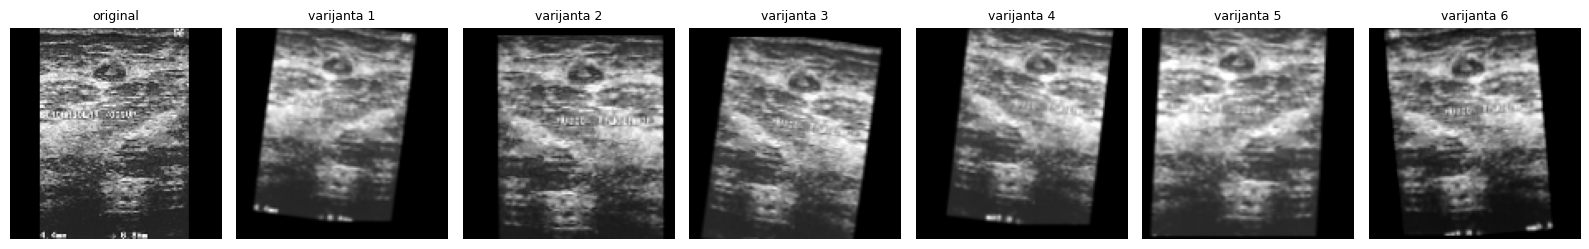

In [42]:
import matplotlib.pyplot as plt
row = data[data["split"]=="train"].sample(1, random_state=3).iloc[0]
img, _ = read_image(row["path"], row["y"], 128)
aug = build_augmentation("weak")

fig, ax = plt.subplots(1, 7, figsize=(16, 2.6))
ax[0].imshow(img[...,0], cmap="gray"); ax[0].set_title("original", fontsize=9)
for i in range(1, 7):
    a = aug(img[None,...], training=True)[0]
    ax[i].imshow(a[...,0], cmap="gray"); ax[i].set_title(f"varijanta {i}", fontsize=9)
for a in ax: a.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"slika_4_3_augmentacija.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.2. Krive obučavanja (Slika 6)

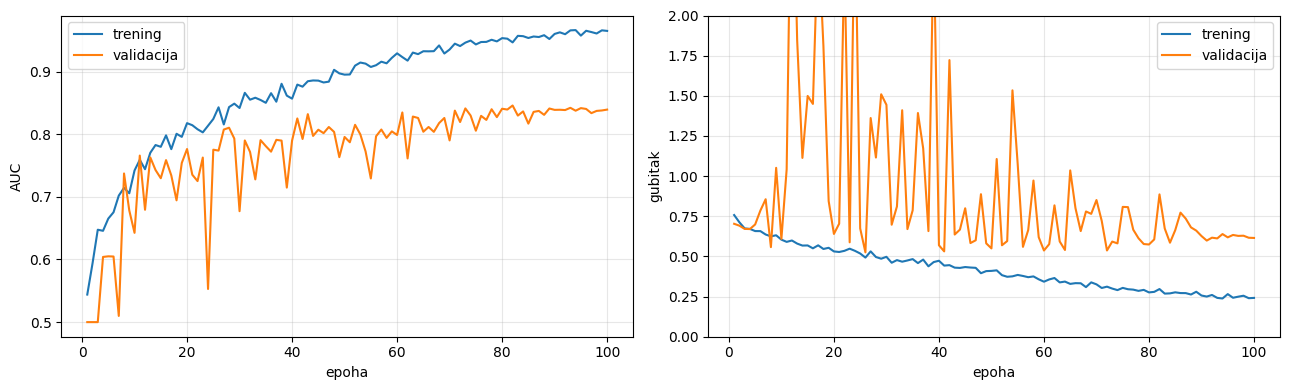

In [43]:
import pandas as pd, matplotlib.pyplot as plt
H = pd.read_csv(next(Path("/kaggle/input").rglob("history_N_image128_s1000.csv")))
H.index += 1
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(H.index, H["auc"], label="trening")
ax[0].plot(H.index, H["val_auc"], label="validacija")
ax[0].set_xlabel("epoha"); ax[0].set_ylabel("AUC"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(H.index, H["loss"], label="trening")
ax[1].plot(H.index, H["val_loss"], label="validacija")
ax[1].set_xlabel("epoha"); ax[1].set_ylabel("gubitak"); ax[1].set_ylim(0,2)
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"slika_5_1_krive_ucenja.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.3. AUC u zavisnosti od broja parametara (Slika 7)

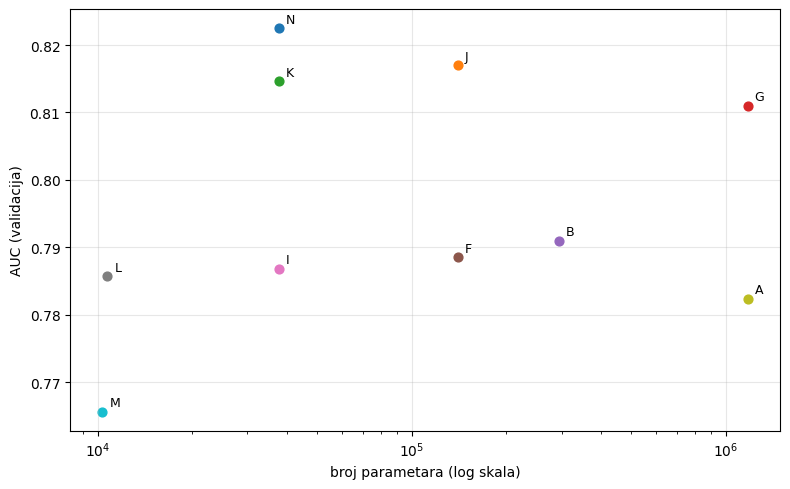

In [44]:
import matplotlib.pyplot as plt
konf = {"N":(37754,0.8225),"J":(140522,0.8170),"K":(37754,0.8146),
        "G":(1174817,0.8110),"B":(294801,0.7910),"F":(140522,0.7885),
        "I":(37754,0.7868),"L":(10754,0.7857),"A":(1174817,0.7824),
        "M":(10362,0.7656)}
fig, ax = plt.subplots(figsize=(8,5))
for ime,(p,auc) in konf.items():
    ax.scatter(p, auc, s=40)
    ax.annotate(ime, (p, auc), textcoords="offset points", xytext=(5,4), fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("broj parametara (log skala)"); ax.set_ylabel("AUC (validacija)")
ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"slika_5_2_parametri_auc.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.4. Primeri grešaka modela (Slika 9)

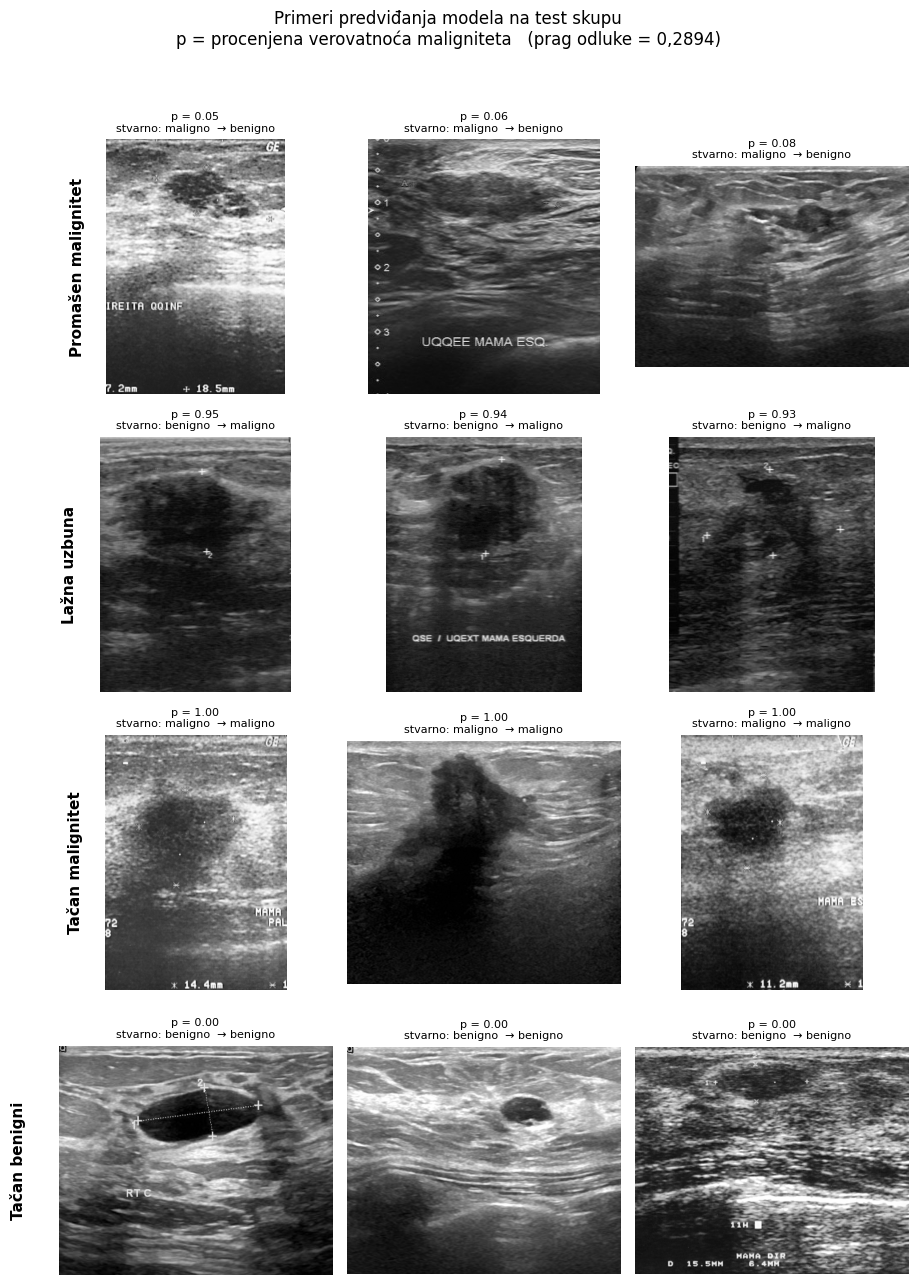

In [45]:
import matplotlib.pyplot as plt
from PIL import Image

pred = pd.read_csv(next(Path("/kaggle/input").rglob("predictions_test_final.csv")))
PRAG = 0.2894                          # prag iz celije 8, ciljana senzitivnost 0,90
pred["pred"] = (pred["p"] >= PRAG).astype(int)

# p = procenjena verovatnoca da je lezija MALIGNA:
#   p -> 1  model siguran u malignitet;  p -> 0  model siguran u benignost
kategorije = [
    ("Promašen malignitet", pred[(pred.y == 1) & (pred.pred == 0)].sort_values("p")),
    ("Lažna uzbuna",        pred[(pred.y == 0) & (pred.pred == 1)].sort_values("p", ascending=False)),
    ("Tačan malignitet",    pred[(pred.y == 1) & (pred.pred == 1)].sort_values("p", ascending=False)),
    ("Tačan benigni",       pred[(pred.y == 0) & (pred.pred == 0)].sort_values("p")),
]

fig, ax = plt.subplots(4, 3, figsize=(9.5, 13))
fig.suptitle("Primeri predviđanja modela na test skupu\n"
             "p = procenjena verovatnoća maligniteta   (prag odluke = 0,2894)",
             fontsize=12, y=0.995)

for r, (naslov, sub) in enumerate(kategorije):
    for c in range(3):
        row = sub.iloc[c]
        img = Image.open(DATA_ROOT / row["rel_path"]).convert("L")
        ax[r, c].imshow(img, cmap="gray")
        stvarno = "maligno" if row["y"] == 1 else "benigno"
        odluka  = "→ maligno" if row["pred"] == 1 else "→ benigno"
        ax[r, c].set_title(f"p = {row['p']:.2f}\nstvarno: {stvarno}  {odluka}",
                           fontsize=8)
        ax[r, c].axis("off")
    # red-oznaka levo od prvog snimka (radi i kad su ose iskljucene)
    ax[r, 0].text(-0.12, 0.5, naslov, transform=ax[r, 0].transAxes,
                  fontsize=11, fontweight="bold", rotation=90,
                  va="center", ha="right")

plt.tight_layout(rect=[0.03, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / "slika_5_6_greske.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.5. Isecanje prema maski (Slika 10)

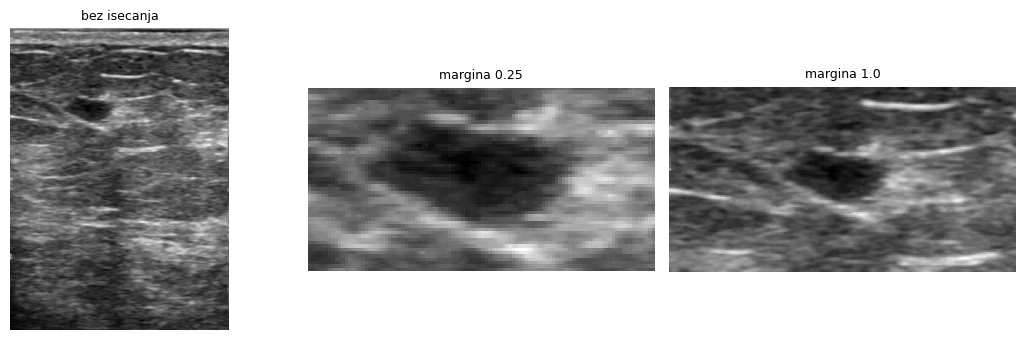

In [46]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
row = data[(data["split"]=="train") & data["mask"].notna()].sample(1, random_state=1).iloc[0]
full = np.asarray(Image.open(row["path"]).convert("L"))
fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
ax[0].imshow(full, cmap="gray"); ax[0].set_title("bez isecanja", fontsize=9)
for i, margin in enumerate([0.25, 1.00], start=1):
    box = expand_boxes(pd.DataFrame([row]), margin)[0]
    ax[i].imshow(full[box[0]:box[2], box[1]:box[3]], cmap="gray")
    ax[i].set_title(f"margina {margin}", fontsize=9)
for a in ax: a.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"slika_5_7_isecanje.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_88             │ (None, 128, 128, 16)   │            25 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_88          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_88 (ReLU)                 │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_89             │ (None, 128, 128, 16)   │           400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_89          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_89 (ReLU)                 │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_90             │ (None, 64, 64, 32)     │           656 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_90          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_90 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_91             │ (None, 64, 64, 32)     │         1,312 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_91          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_91 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_92             │ (None, 32, 32, 64)     │         2,336 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_92          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_92 (ReLU)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_93             │ (None, 32, 32, 64)     │         4,672 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 111,347 (434.96 KB)

 Trainable params: 36,794 (143.73 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 73,593 (287.48 KB)